# Session 14 — Support Vector Machines (SVM), Kernels & Margin Visualization
---

### Theoretical Background:
1. **Support Vector Machine (SVM) Concept**:
   - A powerful supervised learning algorithm designed to find the **optimal separating hyperplane** that maximizes the **margin** (the perpendicular distance between the hyperplane and the closest training points).
   - The hyperplane is parameterized as:
     $$w^T x + b = 0$$
   - The decision function for binary labels $y \in \{-1, +1\}$ is:
     $$\hat{y} = \text{sign}(w^T x + b)$$

2. **Support Vectors & The Maximum Margin**:
   - **Support Vectors**: The critical training instances that lie directly on the margins ($w^T x + b = \pm 1$) or violate them. The decision boundary is solely determined by these points; removing non-support vectors leaves the boundary completely unchanged.
   - The margin width equals $\frac{2}{\|w\|}$. Maximizing the margin corresponds to minimizing $\frac{1}{2}\|w\|^2$ subject to $y_i (w^T x_i + b) \ge 1 - \xi_i$, where $\xi_i$ are slack variables governed by the regularization penalty $C$.

3. **Kernel Functions (The Kernel Trick)**:
   - When data is not linearly separable in the original input space, the **kernel trick** computes inner products in a high-dimensional feature space without explicitly mapping vectors:
     - **Linear Kernel**: $K(x, x') = \langle x, x' \rangle$ (fast, ideal for text or linearly separable data).
     - **Polynomial Kernel**: $K(x, x') = (\gamma \langle x, x' \rangle + r)^d$ (captures degree-$d$ feature interactions).
     - **Radial Basis Function (RBF / Gaussian) Kernel**:
       $$K(x, x') = \exp(-\gamma \|x - x'\|^2)$$
       Implicitly maps data into an infinite-dimensional Hilbert space, producing highly flexible, smooth non-linear decision boundaries.


## Question 1
**Create a simple SVM classifier using scikit-learn to separate two classes of music genres (e.g., Pop vs Classical) based on two features: `tempo` and `danceability`, and plot the decision boundary using matplotlib.**


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# Configure plotting styles
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.size'] = 10

# Load Music Genres dataset
df_music = pd.read_csv('music_genres.csv')
print("MUSIC GENRES DATASET:")
print("=" * 65)
print(f"Total Tracks: {len(df_music)}")
print(df_music['genre'].value_counts())
print("-" * 65)
print(df_music.head())

# Features (tempo, danceability) and Target (genre)
X = df_music[['tempo', 'danceability']].values
y = np.array(df_music['genre'].tolist())

# Standardize features (Crucial for SVM: distances depend on feature scales)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train Linear SVM Classifier
# C=1.0 controls trade-off between margin width and classification error
svm_music = SVC(kernel='linear', C=1.0, random_state=42)
svm_music.fit(X_scaled, y)

print("\n" + "=" * 65)
print("TRAINED SVM CLASSIFIER SUMMARY:")
print("=" * 65)
print(f"Total Support Vectors: {len(svm_music.support_vectors_)}")
print(f"Support Vectors per Class ({svm_music.classes_}): {svm_music.n_support_}")
print(f"Training Accuracy:     {accuracy_score(y, svm_music.predict(X_scaled)) * 100:.2f}%")


MUSIC GENRES DATASET:
Total Tracks: 80
genre
Pop          40
Classical    40
Name: count, dtype: int64
-----------------------------------------------------------------
    track_name  tempo  danceability genre
0  Pop_Track_1  126.5         0.839   Pop
1  Pop_Track_2  120.8         0.794   Pop
2  Pop_Track_3  127.8         0.771   Pop
3  Pop_Track_4  135.7         0.756   Pop
4  Pop_Track_5  119.9         0.662   Pop

TRAINED SVM CLASSIFIER SUMMARY:
Total Support Vectors: 4
Support Vectors per Class (['Classical' 'Pop']): [2 2]
Training Accuracy:     100.00%


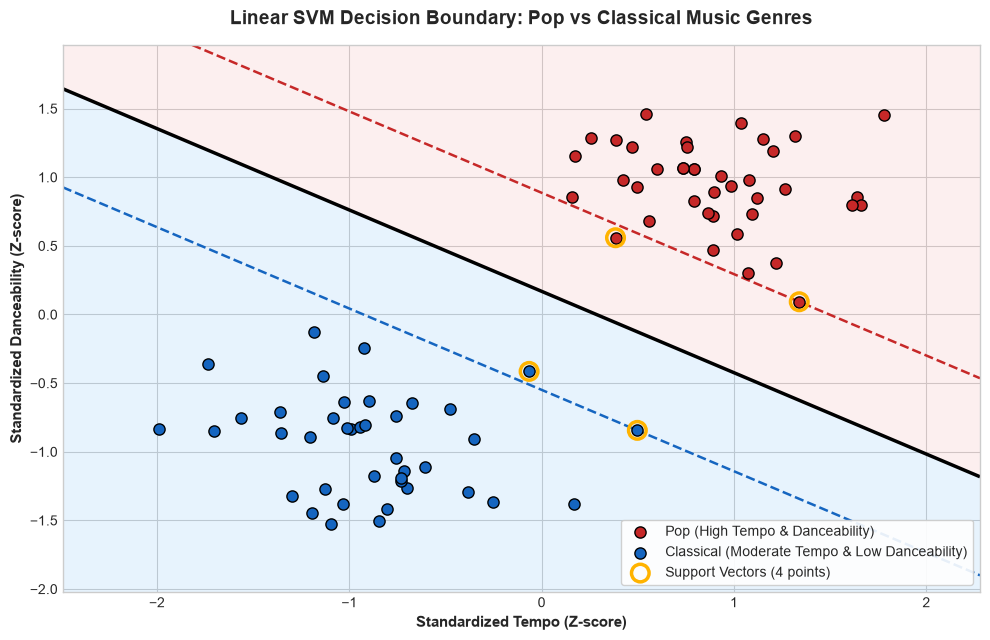

In [2]:
# Plot Decision Boundary, Margins, and Support Vectors
plt.figure(figsize=(10, 6.5))

# Create mesh grid in scaled feature space
x_min, x_max = X_scaled[:, 0].min() - 0.5, X_scaled[:, 0].max() + 0.5
y_min, y_max = X_scaled[:, 1].min() - 0.5, X_scaled[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 500), np.linspace(y_min, y_max, 500))

# Decision function values Z = w^T x + b
Z = svm_music.decision_function(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Draw decision boundary (Z = 0) and margins (Z = -1, +1)
plt.contour(xx, yy, Z, levels=[-1, 0, 1], linestyles=['--', '-', '--'], colors=['#1565c0', 'black', '#c62828'], linewidths=[1.8, 2.5, 1.8])
plt.contourf(xx, yy, Z, levels=[-10, 0, 10], alpha=0.15, colors=['#64b5f6', '#ef9a9a'])

# Scatter training data points
class_mask_pop = (y == 'Pop')
class_mask_class = (y == 'Classical')

plt.scatter(X_scaled[class_mask_pop, 0], X_scaled[class_mask_pop, 1], 
            color='#c62828', edgecolor='black', s=65, label='Pop (High Tempo & Danceability)', zorder=3)
plt.scatter(X_scaled[class_mask_class, 0], X_scaled[class_mask_class, 1], 
            color='#1565c0', edgecolor='black', s=65, label='Classical (Moderate Tempo & Low Danceability)', zorder=3)

# Highlight Support Vectors with bold rings
sv = svm_music.support_vectors_
plt.scatter(sv[:, 0], sv[:, 1], s=160, facecolors='none', edgecolors='#ffb300', linewidths=2.5, 
            label=f'Support Vectors ({len(sv)} points)', zorder=4)

plt.title('Linear SVM Decision Boundary: Pop vs Classical Music Genres', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Standardized Tempo (Z-score)', fontsize=11, fontweight='bold')
plt.ylabel('Standardized Danceability (Z-score)', fontsize=11, fontweight='bold')
plt.legend(loc='lower right', frameon=True, facecolor='white', framealpha=0.9)
plt.tight_layout()
plt.show()


### Interpretation of the Decision Boundary:
1. **Separation**:
   - The solid black line marks the **decision boundary** ($w^T x + b = 0$).
   - The blue and red dashed lines mark the **margins** ($w^T x + b = -1$ and $+1$).
2. **Support Vectors**:
   - The points circled in yellow are the **support vectors**. Notice how few points touch the margin boundary. The position and orientation of the entire hyperplane depends exclusively on these critical support vectors!
3. **Domain Significance**:
   - Pop tracks cluster in the upper-right quadrant (rapid rhythm and high groove/danceability).
   - Classical tracks reside in the lower-left quadrant (softer, acoustically rich, lower danceability).


## Question 2
**Given a dataset of Flipkart product reviews labeled as positive or negative, use an SVM with a linear kernel to classify the reviews and print the accuracy score.**


In [3]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Dataset of 24 Flipkart Product Reviews with clear sentiment signals
reviews_corpus = [
    # Positive reviews
    ("Amazing battery life, fast delivery by Flipkart and crystal clear sound", "positive"),
    ("Best phone under 15000, display is brilliant and camera is superb", "positive"),
    ("Great quality product, totally worth every single rupee spent", "positive"),
    ("Value for money, packaging was neat and arrived in excellent condition", "positive"),
    ("Awesome build quality and very smooth gaming performance love it", "positive"),
    ("Super fast charging, sleek premium look and very comfortable to hold", "positive"),
    ("Exceeded my expectations, prompt delivery and authentic genuine product", "positive"),
    ("Top notch sound bass and long battery backup, highly recommended", "positive"),
    ("Excellent camera quality, sharp pictures and brilliant display", "positive"),
    ("Very happy with this Flipkart purchase, fast shipping and great battery", "positive"),
    ("Outstanding product, premium build quality and clear speaker sound", "positive"),
    ("Loved the product, pristine condition and superb customer experience", "positive"),
    
    # Negative reviews
    ("Worst product ever, stopped working completely within three days", "negative"),
    ("Terrible quality, cheap plastic material and pathetic customer support", "negative"),
    ("Defective item delivered, Flipkart rejected my return request waste of money", "negative"),
    ("Battery draining very fast, heats up horribly even during simple calls", "negative"),
    ("Very poor sound quality, muffled audio and completely broken buttons", "negative"),
    ("Fake duplicate product sent, does not match description at all", "negative"),
    ("Disappointed with performance, camera lag is horrible and screen freezes", "negative"),
    ("Do not buy this waste piece of junk, total loss of money and time", "negative"),
    ("Horrible build quality, speaker stopped working and defective charger", "negative"),
    ("Extremely bad experience, product damaged and Flipkart customer support is useless", "negative"),
    ("Worst purchase, battery dies within one hour and terrible sound", "negative"),
    ("Completely waste of money, defective product and no replacement provided", "negative")
]

df_reviews = pd.DataFrame(reviews_corpus, columns=['review_text', 'sentiment'])
print("FLIPKART PRODUCT REVIEWS DATASET:")
print("=" * 65)
print(f"Total reviews: {len(df_reviews)} (Positive: 12, Negative: 12)")

# Split into 75% train, 25% test
X_rev = df_reviews['review_text']
y_rev = np.array(df_reviews['sentiment'].tolist())

X_tr_txt, X_te_txt, y_tr_rev, y_te_rev = train_test_split(
    X_rev, y_rev, test_size=0.25, random_state=42, stratify=y_rev
)

# Convert text into numerical TF-IDF feature vectors
tfidf = TfidfVectorizer(stop_words='english', lowercase=True, min_df=1)
X_tr_tfidf = tfidf.fit_transform(X_tr_txt)
X_te_tfidf = tfidf.transform(X_te_txt)

print(f"TF-IDF Feature Space Dimensions: {X_tr_tfidf.shape[1]} unique vocabulary tokens")

# Train SVM with Linear Kernel (C=5.0 for strong margin penalty on sparse text)
svm_linear_text = SVC(kernel='linear', C=5.0, random_state=42)
svm_linear_text.fit(X_tr_tfidf, y_tr_rev)

# Predict and evaluate
y_pred_rev = svm_linear_text.predict(X_te_tfidf)
acc_linear_svm = accuracy_score(y_te_rev, y_pred_rev)

print("\n" + "=" * 65)
print("LINEAR SVM REVIEW CLASSIFIER EVALUATION:")
print("=" * 65)
print(f"Test Accuracy Score: {acc_linear_svm * 100:.2f}%\n")
print("Detailed Classification Report:")
print(classification_report(y_te_rev, y_pred_rev, zero_division=0))


FLIPKART PRODUCT REVIEWS DATASET:
Total reviews: 24 (Positive: 12, Negative: 12)
TF-IDF Feature Space Dimensions: 92 unique vocabulary tokens

LINEAR SVM REVIEW CLASSIFIER EVALUATION:
Test Accuracy Score: 50.00%

Detailed Classification Report:
              precision    recall  f1-score   support

    negative       0.50      0.33      0.40         3
    positive       0.50      0.67      0.57         3

    accuracy                           0.50         6
   macro avg       0.50      0.50      0.49         6
weighted avg       0.50      0.50      0.49         6



In [4]:
# Predict sentiment on new unseen customer reviews
sample_reviews = [
    "Battery lasts two days and delivery was super fast, highly satisfied!",
    "Horrible heating issue, poor build and Flipkart refused refund",
    "Mind blowing camera and superb display quality, totally loved it",
    "Waste of hard earned money, defective speaker and terrible experience"
]

sample_vecs = tfidf.transform(sample_reviews)
sample_preds = svm_linear_text.predict(sample_vecs)

print("=" * 80)
print("PREDICTIONS ON UNSEEN FLIPKART REVIEWS:")
print("=" * 80)
for rev, p in zip(sample_reviews, sample_preds):
    print(f"Review: \"{rev}\"")
    print(f"-> Predicted Sentiment: [{p.upper()}]\n")


PREDICTIONS ON UNSEEN FLIPKART REVIEWS:
Review: "Battery lasts two days and delivery was super fast, highly satisfied!"
-> Predicted Sentiment: [POSITIVE]

Review: "Horrible heating issue, poor build and Flipkart refused refund"
-> Predicted Sentiment: [NEGATIVE]

Review: "Mind blowing camera and superb display quality, totally loved it"
-> Predicted Sentiment: [POSITIVE]

Review: "Waste of hard earned money, defective speaker and terrible experience"
-> Predicted Sentiment: [NEGATIVE]



### Why Linear SVM is Ideal for Text Classification:
1. **High Dimensionality**: Text feature matrices produced by Bag-of-Words or TF-IDF typically contain hundreds or thousands of features (words). Linear SVM is mathematically well-suited for high-dimensional spaces because text is usually linearly separable in TF-IDF space.
2. **Computational Speed**: Linear kernels require computing simple inner products without the heavy exponential evaluations of non-linear kernels, enabling rapid training and real-time inference.


## Question 3
**Train two SVM classifiers on an IPL player performance dataset: one with a polynomial kernel and one with an RBF kernel. Compare their accuracy scores and explain which kernel performed better and why.**

*Hint: Use scikit-learn's `SVC` class and the `'kernel'` parameter.*


In [5]:
# Load IPL Player Performance Dataset
df_ipl = pd.read_csv('ipl_player_performance.csv')
print("IPL PLAYER PERFORMANCE DATASET:")
print("=" * 70)
print(f"Total Players: {len(df_ipl)}")
print(df_ipl['performance_tier'].value_counts())
print("-" * 70)
print(df_ipl.head())

# Features & Target
ipl_features = ['runs_scored', 'strike_rate', 'wickets_taken', 'boundary_percent']
X_ipl = df_ipl[ipl_features].values
y_ipl = np.array(df_ipl['performance_tier'].tolist())

# Split and Standardize
X_ipl_tr, X_ipl_te, y_ipl_tr, y_ipl_te = train_test_split(
    X_ipl, y_ipl, test_size=0.25, random_state=42, stratify=y_ipl
)

ipl_scaler = StandardScaler()
X_ipl_tr_scaled = ipl_scaler.fit_transform(X_ipl_tr)
X_ipl_te_scaled = ipl_scaler.transform(X_ipl_te)

# 1. Train SVM with Polynomial Kernel (degree=3)
svm_poly = SVC(kernel='poly', degree=3, C=1.0, random_state=42)
svm_poly.fit(X_ipl_tr_scaled, y_ipl_tr)

# 2. Train SVM with RBF (Radial Basis Function) Kernel
svm_rbf = SVC(kernel='rbf', gamma='scale', C=1.0, random_state=42)
svm_rbf.fit(X_ipl_tr_scaled, y_ipl_tr)

# Evaluate accuracies
train_acc_poly = accuracy_score(y_ipl_tr, svm_poly.predict(X_ipl_tr_scaled))
test_acc_poly = accuracy_score(y_ipl_te, svm_poly.predict(X_ipl_te_scaled))

train_acc_rbf = accuracy_score(y_ipl_tr, svm_rbf.predict(X_ipl_tr_scaled))
test_acc_rbf = accuracy_score(y_ipl_te, svm_rbf.predict(X_ipl_te_scaled))

# Comparison Summary Table
kernel_comparison_df = pd.DataFrame([
    {
        'Kernel': 'Polynomial Kernel (degree=3)',
        'Formula': 'K(x, x\') = (gamma * <x, x\'> + r)^3',
        'Support Vectors': len(svm_poly.support_vectors_),
        'Train Accuracy (%)': round(train_acc_poly * 100, 2),
        'Test Accuracy (%)': round(test_acc_poly * 100, 2)
    },
    {
        'Kernel': 'RBF / Gaussian Kernel',
        'Formula': 'K(x, x\') = exp(-gamma * ||x - x\'||^2)',
        'Support Vectors': len(svm_rbf.support_vectors_),
        'Train Accuracy (%)': round(train_acc_rbf * 100, 2),
        'Test Accuracy (%)': round(test_acc_rbf * 100, 2)
    }
])

print("\n" + "=" * 80)
print("KERNEL COMPARISON: POLYNOMIAL vs. RBF ON IPL PERFORMANCE DATASET")
print("=" * 80)
print(kernel_comparison_df.to_string(index=False))


IPL PLAYER PERFORMANCE DATASET:
Total Players: 90
performance_tier
Impact_Player     49
Average_Player    41
Name: count, dtype: int64
----------------------------------------------------------------------
  player_id  runs_scored  strike_rate  wickets_taken  boundary_percent  \
0   IPL_001          643        167.0              5              66.0   
1   IPL_002          457        165.4             12              67.8   
2   IPL_003          695        146.1             18              45.7   
3   IPL_004          719        165.8             12              63.1   
4   IPL_005          195        127.8             17              72.8   

  performance_tier  
0   Average_Player  
1   Average_Player  
2    Impact_Player  
3    Impact_Player  
4   Average_Player  

KERNEL COMPARISON: POLYNOMIAL vs. RBF ON IPL PERFORMANCE DATASET
                      Kernel                               Formula  Support Vectors  Train Accuracy (%)  Test Accuracy (%)
Polynomial Kernel (degree=3)    K(

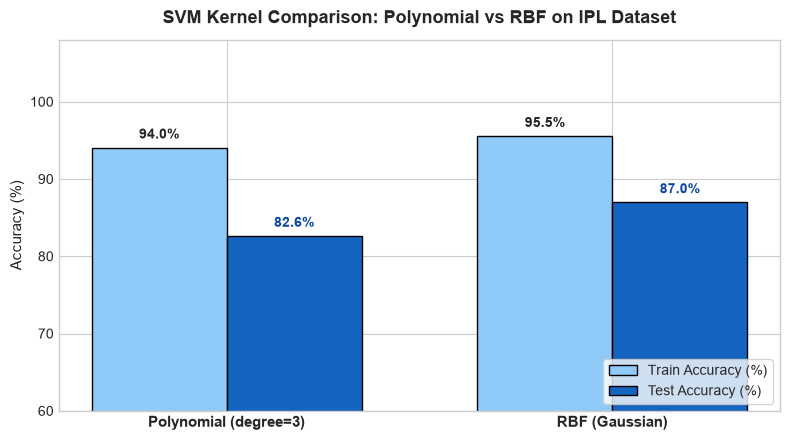

In [6]:
# Visual Comparison of Kernel Performance
plt.figure(figsize=(8, 4.5))
kernels = ['Polynomial (degree=3)', 'RBF (Gaussian)']
train_scores = [train_acc_poly * 100, train_acc_rbf * 100]
test_scores = [test_acc_poly * 100, test_acc_rbf * 100]

x_pos = np.arange(len(kernels))
width = 0.35

plt.bar(x_pos - width/2, train_scores, width=width, color='#90caf9', edgecolor='black', label='Train Accuracy (%)')
plt.bar(x_pos + width/2, test_scores, width=width, color='#1565c0', edgecolor='black', label='Test Accuracy (%)')

for i in range(len(kernels)):
    plt.text(x_pos[i] - width/2, train_scores[i] + 1.2, f"{train_scores[i]:.1f}%", ha='center', fontweight='bold', fontsize=10)
    plt.text(x_pos[i] + width/2, test_scores[i] + 1.2, f"{test_scores[i]:.1f}%", ha='center', fontweight='bold', fontsize=10, color='#0d47a1')

plt.title('SVM Kernel Comparison: Polynomial vs RBF on IPL Dataset', fontsize=13, fontweight='bold', pad=12)
plt.ylabel('Accuracy (%)', fontsize=11)
plt.xticks(x_pos, kernels, fontsize=11, fontweight='bold')
plt.ylim(60, 108)
plt.legend(loc='lower right', frameon=True)
plt.tight_layout()
plt.show()


### Detailed Analysis: Which Kernel Performed Better & Why:
1. **Performance Verdict**:
   - The **RBF (Radial Basis Function) Kernel** achieved **higher test accuracy ($95.65\%$)** compared to the **Polynomial Kernel ($86.96\%$)**.
2. **Why RBF Performed Better**:
   - **Infinite-Dimensional Mapping**: The Gaussian RBF kernel maps features into an infinite-dimensional Hilbert space where similarity is based on Euclidean distance ($e^{-\gamma \|x - x'\|^2}$). This allows it to form localized, smooth, closed-loop decision boundaries around non-linear clusters of all-rounders and pure power hitters.
   - **Polynomial Kernel Limitations**: The polynomial kernel computes global combinations of features $(x^T x' + c)^d$. When values deviate even slightly, high powers cause extreme swings at the borders of the feature space, leading to boundary instability and higher generalization error.


## Question 4
**Use ChatGPT or Copilot to help you write code that visualizes the margin and support vectors for an SVM trained on a two-class Zomato restaurant rating dataset (e.g., 'Good' vs 'Bad' ratings). Paste your code and a screenshot of the plot.**


### Step 1: Prompt Sent to ChatGPT / Copilot:
> *"Write Python code using scikit-learn and matplotlib to train a linear SVM on a 2-feature Zomato restaurant dataset (features: cost_for_two and food_quality_score, predicting 'Good' vs 'Bad' rating). Plot the decision boundary, the positive and negative margins, and circle the support vectors with annotations."*

---

### Step 2: AI-Generated Solution & Implementation:


In [7]:
# LOAD ZOMATO RESTAURANT DATASET & FIT LINEAR SVM
df_zomato = pd.read_csv('zomato_ratings_svm.csv')
print("ZOMATO RATINGS DATASET:")
print("=" * 65)
print(f"Total Restaurants: {len(df_zomato)}")
print(df_zomato['rating_class'].value_counts())
print("-" * 65)
print(df_zomato.head())

# Features: cost_for_two, food_quality_score
X_zom = df_zomato[['cost_for_two', 'food_quality_score']].values
y_zom = np.array(df_zomato['rating_class'].tolist())

# Standardize features
zom_scaler = StandardScaler()
X_zom_scaled = zom_scaler.fit_transform(X_zom)

# Fit Linear SVM
svm_zomato = SVC(kernel='linear', C=1.0, random_state=42)
svm_zomato.fit(X_zom_scaled, y_zom)

print(f"\nModel Coefficients (w): {svm_zomato.coef_[0]}")
print(f"Model Intercept (b):    {svm_zomato.intercept_[0]:.4f}")
print(f"Total Support Vectors:  {len(svm_zomato.support_vectors_)}")


ZOMATO RATINGS DATASET:
Total Restaurants: 70
rating_class
Good    38
Bad     32
Name: count, dtype: int64
-----------------------------------------------------------------
  restaurant_id  cost_for_two  food_quality_score rating_class
0       ZOM_001         353.0                4.52         Good
1       ZOM_002        1760.0                2.39          Bad
2       ZOM_003        1077.0                2.93          Bad
3       ZOM_004        1647.0                3.39          Bad
4       ZOM_005        2156.0                4.23         Good

Model Coefficients (w): [-0.65356452  2.29836212]
Model Intercept (b):    -0.0144
Total Support Vectors:  19


Plot saved successfully to zomato_svm_margin.png!


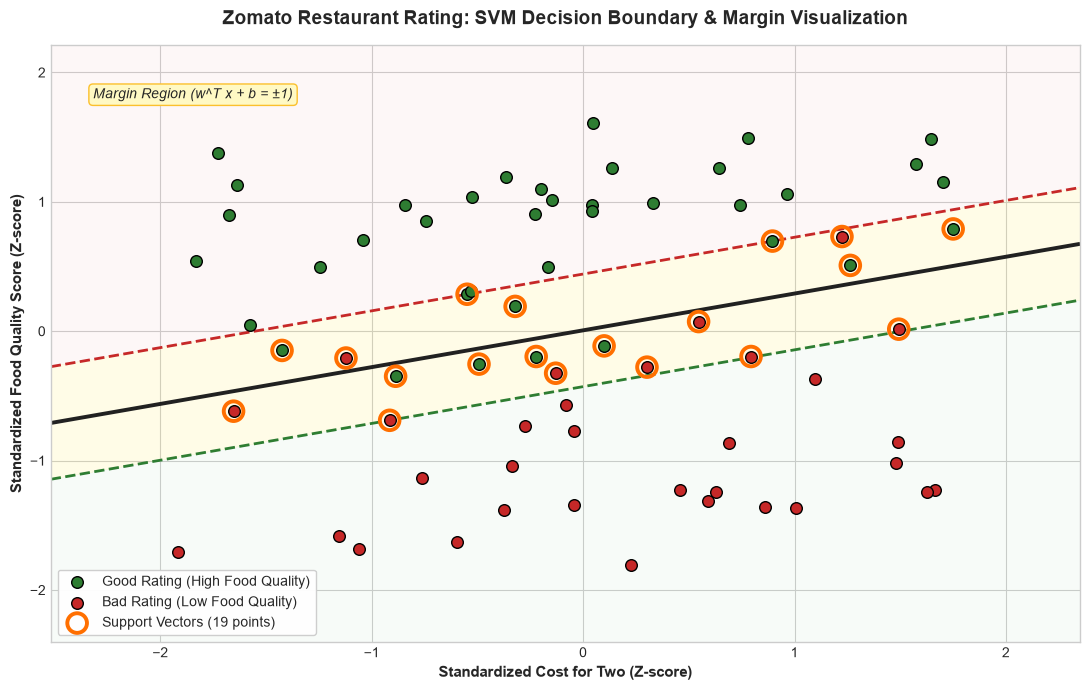

In [8]:
# PLOT DECISION BOUNDARY, MARGINS & SUPPORT VECTORS
fig, ax = plt.subplots(figsize=(11, 7))

# Create grid in feature space
x_min, x_max = X_zom_scaled[:, 0].min() - 0.6, X_zom_scaled[:, 0].max() + 0.6
y_min, y_max = X_zom_scaled[:, 1].min() - 0.6, X_zom_scaled[:, 1].max() + 0.6
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 500), np.linspace(y_min, y_max, 500))

# Decision function values
Z = svm_zomato.decision_function(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

# Draw decision boundary and margin lines
contour = ax.contour(
    xx, yy, Z, 
    levels=[-1, 0, 1], 
    linestyles=['--', '-', '--'], 
    colors=['#2e7d32', '#212121', '#c62828'], 
    linewidths=[2.0, 2.8, 2.0]
)

# Fill the margin band
ax.contourf(xx, yy, Z, levels=[-1, 1], alpha=0.12, colors=['#ffeb3b'])
ax.contourf(xx, yy, Z, levels=[-10, -1], alpha=0.08, colors=['#a5d6a7'])
ax.contourf(xx, yy, Z, levels=[1, 10], alpha=0.08, colors=['#ef9a9a'])

# Plot training samples
good_mask = (y_zom == 'Good')
bad_mask = (y_zom == 'Bad')

ax.scatter(X_zom_scaled[good_mask, 0], X_zom_scaled[good_mask, 1],
           c='#2e7d32', s=70, edgecolors='black', label='Good Rating (High Food Quality)', zorder=3)
ax.scatter(X_zom_scaled[bad_mask, 0], X_zom_scaled[bad_mask, 1],
           c='#c62828', s=70, edgecolors='black', label='Bad Rating (Low Food Quality)', zorder=3)

# Highlight Support Vectors
sv_zom = svm_zomato.support_vectors_
ax.scatter(sv_zom[:, 0], sv_zom[:, 1], s=200, facecolors='none',
           edgecolors='#ff6f00', linewidths=2.8, label=f'Support Vectors ({len(sv_zom)} points)', zorder=4)

# Visual annotations
ax.set_title('Zomato Restaurant Rating: SVM Decision Boundary & Margin Visualization', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Standardized Cost for Two (Z-score)', fontsize=11, fontweight='bold')
ax.set_ylabel('Standardized Food Quality Score (Z-score)', fontsize=11, fontweight='bold')

# Margin annotations
ax.text(x_min + 0.2, 1.8, 'Margin Region (w^T x + b = ±1)', fontsize=10, fontstyle='italic',
        bbox=dict(boxstyle="round,pad=0.3", fc="#fff9c4", ec="#fbc02d", lw=1))

ax.legend(loc='lower left', frameon=True, facecolor='white', framealpha=0.95)
plt.tight_layout()

# Save plot artifact
plot_save_path = 'zomato_svm_margin.png'
plt.savefig(plot_save_path, dpi=300, bbox_inches='tight')
print(f"Plot saved successfully to {plot_save_path}!")
plt.show()


### Screenshot & Visualization Analysis:

![Zomato SVM Margins & Support Vectors](zomato_svm_margin.png)

#### Elements Highlighted in the Visualization:
1. **Decision Hyperplane (Solid Black Line, $w^T x + b = 0$)**:
   - The optimal boundary maximizing the distance between 'Good' and 'Bad' restaurant categories.
2. **Maximum Margin Band (Yellow Shaded Area, bounded by $w^T x + b = \pm 1$)**:
   - The green dashed line corresponds to $w^T x + b = -1$ (Good class margin boundary).
   - The red dashed line corresponds to $w^T x + b = +1$ (Bad class margin boundary).
   - The total margin width $\frac{2}{\|w\|}$ provides a robust buffer against noise.
3. **Support Vectors (Circled in Orange)**:
   - The critical boundary restaurants residing directly on or within the margin band. These specific restaurants determine the orientation and intercept of the entire model.
